<a href="https://colab.research.google.com/github/HelloPenguin1/Spine_Lesion_Classification_Using_BasicML/blob/main/image_preprocessing_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [9]:
img = cv2.imread('/content/img2.png', 0)


array([[21,  0,  0, ...,  0,  0,  0],
       [16,  0,  0, ...,  0,  0,  0],
       [16,  0,  0, ...,  0,  0,  0],
       ...,
       [21,  0,  0, ...,  0,  0,  0],
       [21,  0,  0, ...,  0,  0,  0],
       [21,  0,  0, ...,  0,  0,  0]], dtype=uint8)
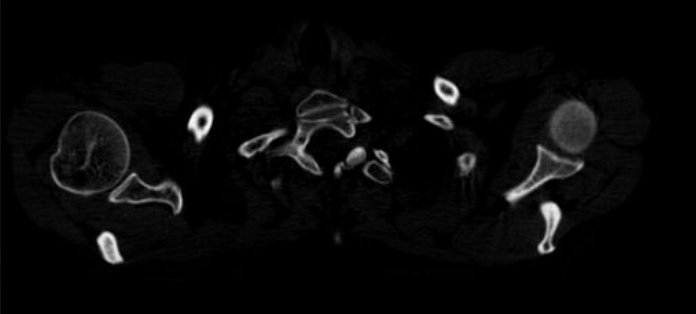

In [10]:
img

In [11]:
equ = cv2.equalizeHist(img)
res = np.hstack((img, equ))

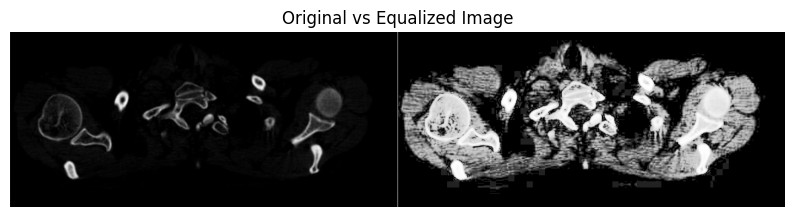

In [12]:
plt.figure(figsize=(10, 5))
plt.imshow(res, cmap='gray')
plt.title("Original vs Equalized Image")
plt.axis('off')
plt.show()

In [22]:
# Obtain the number of rows and columns
# of the image
m, n = res.shape

# Traverse the image. For every 3X3 area,
# find the median of the pixels and
# replace the center pixel by the median
img_new1 = np.zeros([m, n])

for i in range(1, m-1):
    for j in range(1, n-1):
        temp = [res[i-1, j-1],
               res[i-1, j],
               res[i-1, j + 1],
               res[i, j-1],
               res[i, j],
               res[i, j + 1],
               res[i + 1, j-1],
               res[i + 1, j],
               res[i + 1, j + 1]]

        temp = sorted(temp)
        img_new1[i, j]= temp[4]

img_new1 = img_new1.astype(np.uint8)

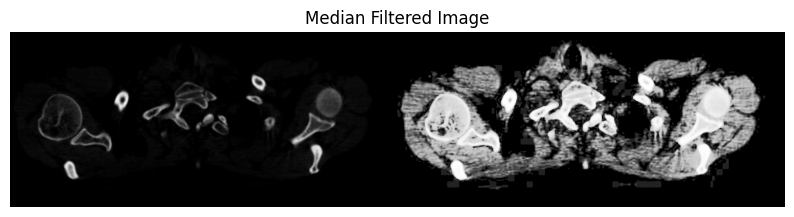

In [24]:
plt.figure(figsize=(10, 5))
plt.imshow(img_new1, cmap='gray')
plt.title("Median Filtered Image")
plt.axis('off')
plt.show()

## Image Enhancement Techniques

Here we will explore various techniques to enhance the `img` (CT image).

### 1. Contrast Limited Adaptive Histogram Equalization (CLAHE)

CLAHE is an advanced form of histogram equalization that enhances the contrast of images by dividing them into small regions called "tiles." It then applies histogram equalization to each tile, and the neighboring tiles are combined using bilinear interpolation to remove artificially induced boundaries. This is especially useful for medical images like CT scans where local contrast can vary significantly.

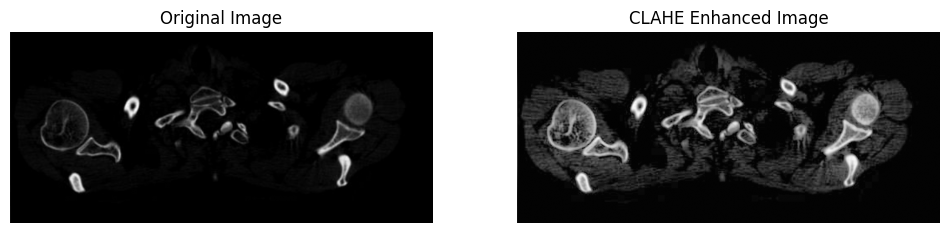

In [27]:
# Apply CLAHE
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

# Display Original vs. CLAHE Enhanced
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clahe_img, cmap='gray')
plt.title('CLAHE Enhanced Image')
plt.axis('off')

plt.show()

### 2. Gamma Correction

Gamma correction is a non-linear operation used to encode and decode luminance values. It's often used to control the overall brightness of an image. For medical images, adjusting the gamma can help in making subtle details more visible by changing the relationship between the pixel values and their perceived brightness. A gamma value less than 1 will brighten the image, while a value greater than 1 will darken it.

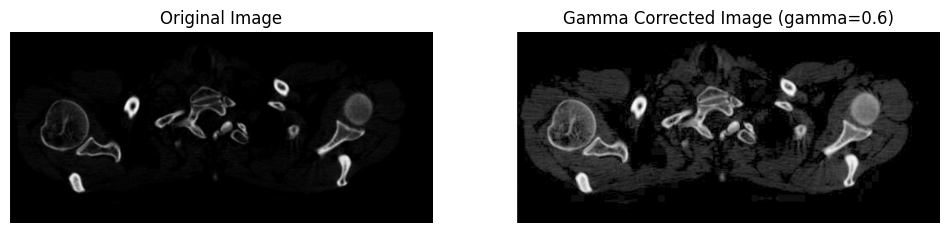

In [37]:
# Apply Gamma Correction
def adjust_gamma(image, gamma=1.0):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                      for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

# Experiment with different gamma values
gamma_img = adjust_gamma(img, gamma=2.0) # Example: brightening the image

# Display Original vs. Gamma Corrected
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gamma_img, cmap='gray')
plt.title('Gamma Corrected Image (gamma=0.6)')
plt.axis('off')

plt.show()

### 3. Unsharp Masking

Unsharp masking is an image sharpening technique. It works by creating a blurred version of the image, subtracting it from the original to create an "unsharp mask," and then adding a portion of this mask back to the original image. This process enhances edges and fine details, which can be crucial for identifying structures in CT scans.

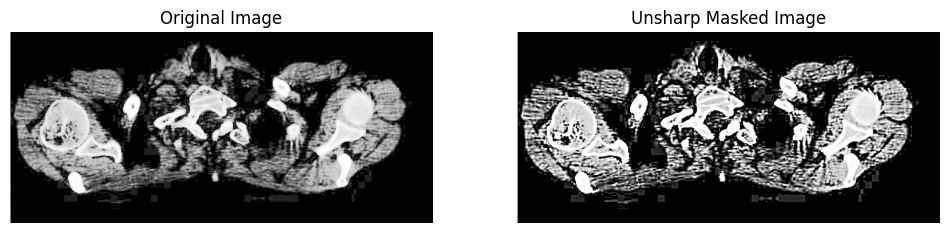

In [35]:
# Apply Unsharp Masking
# Convert image to float to avoid overflow issues during subtraction
img_float = equ.astype(np.float32)

# Blur the image
blurred = cv2.GaussianBlur(img_float, (0, 0), 3) # Kernel size and sigma can be adjusted

# Calculate the unsharp mask
unsharp_mask = img_float - blurred

# Add the mask back to the original image
# The 'amount' parameter controls the strength of the sharpening
unsharp_img = cv2.addWeighted(img_float, 1.0, unsharp_mask, 1.5, 0) # 1.5 is the amount here

# Clip values to valid range and convert back to uint8
unsharp_img = np.clip(unsharp_img, 0, 255).astype(np.uint8)

# Display Original vs. Unsharp Masked
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(equ, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(unsharp_img, cmap='gray')
plt.title('Unsharp Masked Image')
plt.axis('off')

plt.show()